# 04 — Deep-dive per product

Per-product card grid for the `llm_world_20` fashion-retail scenario.
Shows lifecycle stage, freshness multiplier, seasonal multiplier, demand,
sales, inventory, and orders per SKU.

Set `ACTIVE_ONLY = True` to show only products currently in an active
lifecycle stage (not `dead`); `False` shows all 20 products.

Replaces `04-deep_dive_per_product` and `04a-deep_dive_active_only`.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
import math
from dataclasses import replace
from datetime import datetime
from pathlib import Path

while not (Path.cwd() / 'pyproject.toml').exists():
    os.chdir('..')

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi'] = 80
plt.rcParams['savefig.dpi'] = 80

In [2]:
from src.sim.distributions import Uniform
from src.sim.inspect import per_product_df
from src.sim.node import DemandSinkNode, FactoryNode, IntermediateNode
from src.sim.policy import DefaultDemandSinkPolicy, OrderUpToPolicy, StaticFactoryPolicy
from src.sim.runner import Runner
from src.sim.scenario import DisruptionParams, ItemLifecycleParams, Scenario
from src.sim.world import World, world_to_graph

## Configuration

`ACTIVE_ONLY = True` — show only non-dead products.
`ACTIVE_ONLY = False` — show all 20 products.

In [3]:
ACTIVE_ONLY: bool = True  # toggle here

## 1. Build scenario and run

Uses the same `llm_world_20`-style build as `03-run-and-inspect-simulation`.

In [4]:
WORLD_PATH = Path('data/worlds/fashion_retail_20/world.json')
N_STEPS = 120
WORLD_SEED = 42

world = World.from_json(WORLD_PATH)
_base = next(iter(world.store_templates.values()))
template = replace(
    _base,
    id='flagship_20_0',
    capacity=400,
    init_balance=500_000.0,
    init_active_count=10,
    init_freshness='baseline',
    init_stock_pct=0.0,
    order_fee=10.0,
)
world = replace(world, store_templates={'flagship_20_0': template})
topology = world_to_graph(world, sink_density=1.0)

shop_idx = 0
for ni in topology['node_instances']:
    node = ni.node
    if isinstance(node, FactoryNode):
        ni.policy = StaticFactoryPolicy(
            capacity_per_tick=node.capacity_per_tick,
            unit_cost=node.unit_cost,
        )
    elif isinstance(node, IntermediateNode):
        ni.policy = OrderUpToPolicy(policy_seed=1000 + shop_idx, cover_horizon_ticks=30)
        shop_idx += 1
    elif isinstance(node, DemandSinkNode):
        ni.policy = DefaultDemandSinkPolicy()

_STAGES = ['introduction', 'growth', 'maturity', 'decline', 'dead']
scenario = Scenario.from_world(
    world,
    disruption=DisruptionParams(
        event_prob=0.03,
        types=['natural_disaster', 'economic_crisis', 'pandemic', 'political_unrest'],
        regions=world.market.regions,
        severity=Uniform(0.005, 0.02),
        duration=Uniform(5, 20),
    ),
    item_lifecycle=ItemLifecycleParams(
        stages=_STAGES,
        init_stage='maturity',
        default_stage_change_probs={
            'introduction': 0.004,
            'growth': 0.003,
            'maturity': 0.0005,
            'decline': 0.005,
            'dead': 0.0001,
        },
    ),
    nodes=topology['node_instances'],
    edges=topology['edges'],
    n_steps=N_STEPS,
    start_date=datetime(2024, 1, 1),
    world_seed=WORLD_SEED,
)

run_log = Runner(scenario).run()
print(f'Ran {run_log["n_steps"]} ticks, {len(scenario.catalog)} catalog items.')

Ran 120 ticks, 20 catalog items.


## 2. Build per-product DataFrame via `src/sim/inspect.py`

Pull per-`(tick, pid)` series for the shop node using `per_product_df`.

In [5]:
# Identify the shop (IntermediateNode).
shop_id = next(
    ni.node.id for ni in scenario.nodes if isinstance(ni.node, IntermediateNode)
)
print(f'Shop: {shop_id}')

pp = per_product_df(run_log, scenario, shop_id)
print(f'per_product_df shape: {pp.shape}')
pp.head(6)

Shop: flagship_20_0-shop
per_product_df shape: (2400, 6)


,tick,node_id,pid,inventory,pending,orders
0,1,flagship_20_0-shop,P0000,20,0,0
1,1,flagship_20_0-shop,P0001,14,0,0
2,1,flagship_20_0-shop,P0002,14,0,0
3,1,flagship_20_0-shop,P0003,14,0,0
4,1,flagship_20_0-shop,P0004,14,0,0
5,1,flagship_20_0-shop,P0005,14,0,0


In [6]:
# Build product metadata from run_log global section.
products_meta = run_log.get('global', {}).get('products', {})

# Catalog lookup: pid -> name, unit_cost, base_price.
catalog_map = {w.product_id: w for w in scenario.catalog}

# Determine lifecycle stage at last tick (list has one entry per step).
def last_stage(pid: str) -> str:
    stages = products_meta.get(pid, {}).get('lifecycle_stage', ['maturity'])
    return stages[-1] if stages else 'maturity'

# Products to show.
all_pids = sorted(pp['pid'].unique())
if ACTIVE_ONLY:
    pids = [p for p in all_pids if last_stage(p) != 'dead']
else:
    pids = all_pids

print(f'Showing {len(pids)} / {len(all_pids)} products '
      f'(ACTIVE_ONLY={ACTIVE_ONLY})')

Showing 20 / 20 products (ACTIVE_ONLY=True)


## 3. Per-product card grid

One card per SKU: inventory, pending, and orders over the simulation run.
Title includes the product name and final lifecycle stage.

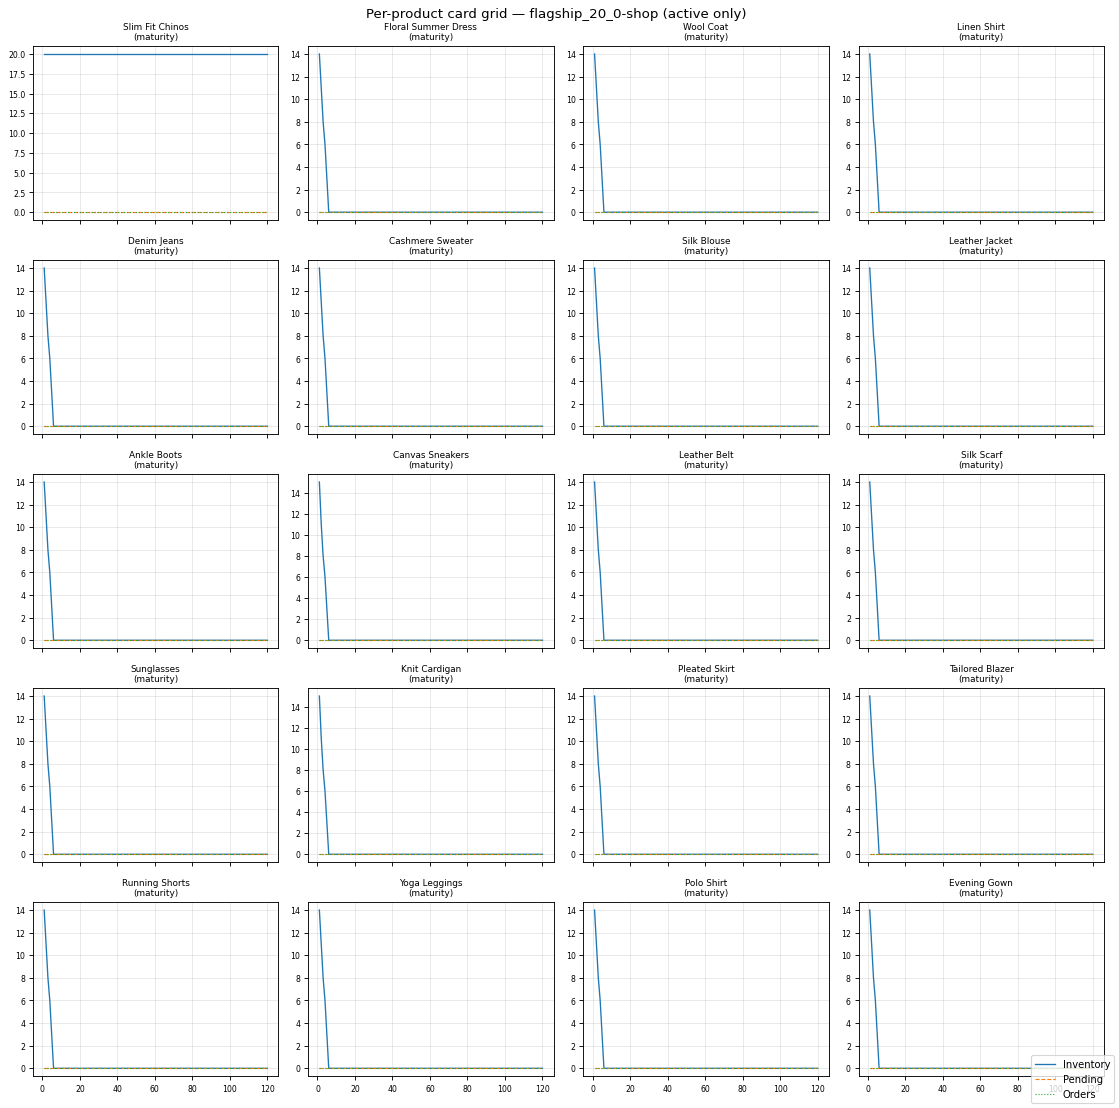

In [7]:
NCOLS = 4
nrows = math.ceil(len(pids) / NCOLS)

fig, axes = plt.subplots(
    nrows, NCOLS,
    figsize=(NCOLS * 3.5, nrows * 2.8),
    sharex=True,
)
axes_flat = axes.flatten() if nrows > 1 else [axes] if NCOLS == 1 else axes.flatten()

for idx, pid in enumerate(pids):
    ax = axes_flat[idx]
    sub = pp[pp['pid'] == pid].sort_values('tick')
    item = catalog_map.get(pid)
    name = item.name if item else pid
    stage = last_stage(pid)

    ax.plot(sub['tick'], sub['inventory'], label='Inventory', linewidth=1.2)
    ax.plot(sub['tick'], sub['pending'], label='Pending', linewidth=1.0, linestyle='--')
    ax.plot(sub['tick'], sub['orders'], label='Orders', linewidth=1.0, linestyle=':')
    ax.set_title(f'{name}\n({stage})', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

# Hide unused axes.
for ax in axes_flat[len(pids):]:
    ax.set_visible(False)

# Single legend outside.
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower right', fontsize=9)
fig.suptitle(
    f'Per-product card grid — {shop_id} '
    f'({"active only" if ACTIVE_ONLY else "all products"})',
    fontsize=12,
)
fig.tight_layout()
plt.show()

## 4. Product lifecycle stage summary

Final lifecycle stage for every product.

In [8]:
stage_summary = [
    {
        'pid': pid,
        'name': (catalog_map.get(pid).name if catalog_map.get(pid) else pid),
        'final_stage': last_stage(pid),
        'freshness_alpha': products_meta.get(pid, {}).get('freshness_alpha', None),
        'freshness_decay': products_meta.get(pid, {}).get('freshness_decay', None),
    }
    for pid in all_pids
]
stage_df = pd.DataFrame(stage_summary)
stage_df

,pid,name,final_stage,freshness_alpha,freshness_decay
0,P0000,Slim Fit Chinos,maturity,0.0,1.0
1,P0001,Floral Summer Dress,maturity,0.0,1.0
2,P0002,Wool Coat,maturity,0.0,1.0
3,P0003,Linen Shirt,maturity,0.0,1.0
4,P0004,Denim Jeans,maturity,0.0,1.0
5,P0005,Cashmere Sweater,maturity,0.0,1.0
6,P0006,Silk Blouse,maturity,0.0,1.0
7,P0007,Leather Jacket,maturity,0.0,1.0
8,P0008,Ankle Boots,maturity,0.0,1.0
9,P0009,Canvas Sneakers,maturity,0.0,1.0


In [9]:
# Stage counts.
stage_df['final_stage'].value_counts().rename('count').to_frame()

,count
final_stage,
maturity,20
